In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import tensorflow as tf

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [ ]:
df = pd.read_csv("dataset.csv")
df.shape

(182994, 14)

In [ ]:
df.head()

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4.0,3441.0,4.0,557.0,1239.0,33.0,14.0,21.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1.0,1900.0,1.0,1400.0,1400.0,1.0,2.0,2.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,NaN,1.0,1.0,1900.0,1.0,1900.0,1900.0,1.0,0.0,0.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,NaN,1.0,6.0,6900.0,5.0,600.0,1800.0,1.0,1.0,2.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,NaN,1.0,3.0,3900.0,3.0,1100.0,1600.0,6.0,6.0,9.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182994 entries, 0 to 182993
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   market_id                 182070 non-null  float64
 1   created_at                182994 non-null  object 
 2   actual_delivery_time      182987 non-null  object 
 3   store_id                  182994 non-null  object 
 4   store_primary_category    178363 non-null  object 
 5   order_protocol            182058 non-null  float64
 6   total_items               182993 non-null  float64
 7   subtotal                  182993 non-null  float64
 8   num_distinct_items        182993 non-null  float64
 9   min_item_price            182993 non-null  float64
 10  max_item_price            182993 non-null  float64
 11  total_onshift_partners    167791 non-null  float64
 12  total_busy_partners       167791 non-null  float64
 13  total_outstanding_orders  167791 non-null  f

In [ ]:
df.isnull().sum()

,0
market_id,924
created_at,0
actual_delivery_time,7
store_id,0
store_primary_category,4631
order_protocol,936
total_items,1
subtotal,1
num_distinct_items,1
min_item_price,1


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
df["actual_delivery_time"] = pd.to_datetime(df["actual_delivery_time"], errors="coerce")


df = df.dropna(subset=["created_at", "actual_delivery_time"])

In [ ]:
df["delivery_time_minutes"] = (df["actual_delivery_time"] - df["created_at"]).dt.total_seconds() / 60.0

In [ ]:
df = df[(df["delivery_time_minutes"] > 0) & (df["delivery_time_minutes"] <= 240)]     # removing outliers

In [ ]:
df["store_primary_category"] = df["store_primary_category"].fillna("unknown")
df["store_primary_category"] = df["store_primary_category"].replace("", "unknown")

In [ ]:
df["market_id"] = df["market_id"].fillna(df["market_id"].mode()[0])
df["order_protocol"] = df["order_protocol"].fillna(df["order_protocol"].mode()[0])

In [ ]:
for col in ["total_onshift_partners", "total_busy_partners", "total_outstanding_orders"]:
    df[col] = df[col].fillna(df[col].median())
    df[col] = df[col].clip(lower=0)

In [ ]:
df = df[(df["subtotal"] >= 0) & (df["min_item_price"] >= 0) & (df["max_item_price"] >= 0)]
df = df[df["total_items"] > 0]

In [ ]:
for col in ["total_items", "subtotal", "num_distinct_items",
                "min_item_price", "max_item_price", "total_onshift_partners",
                "total_busy_partners", "total_outstanding_orders"]:
        upper = df[col].quantile(0.995)
        df[col] = df[col].clip(upper=upper)

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
df["order_hour"] = df["created_at"].dt.hour
df["order_day_of_week"] = df["created_at"].dt.dayofweek  # 0=Mon
df["order_is_weekend"] = df["order_day_of_week"].isin([5, 6]).astype(int)


df["hour_sin"] = np.sin(2 * np.pi * df["order_hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["order_hour"] / 24)

In [ ]:
df["price_range"] = df["max_item_price"] - df["min_item_price"]
df["avg_item_price"] = df["subtotal"] / df["total_items"].replace(0, 1)
df["items_per_distinct"] = df["total_items"] / df["num_distinct_items"].replace(0, 1)

In [ ]:
df["busy_partner_ratio"] = df["total_busy_partners"] / (df["total_onshift_partners"] + 1)
df["available_partners"] = df["total_onshift_partners"] - df["total_busy_partners"]
df["available_partners"] = df["available_partners"].clip(lower=0)
df["outstanding_per_partner"] = df["total_outstanding_orders"] / (df["total_onshift_partners"] + 1)

In [ ]:
top_categories = df["store_primary_category"].value_counts().nlargest(20).index
df["store_primary_category"] = df["store_primary_category"].apply(
    lambda x: x if x in top_categories else "other"
)

In [ ]:
df["market_id"] = df["market_id"].astype(int).astype(str)
df["order_protocol"] = df["order_protocol"].astype(int).astype(str)

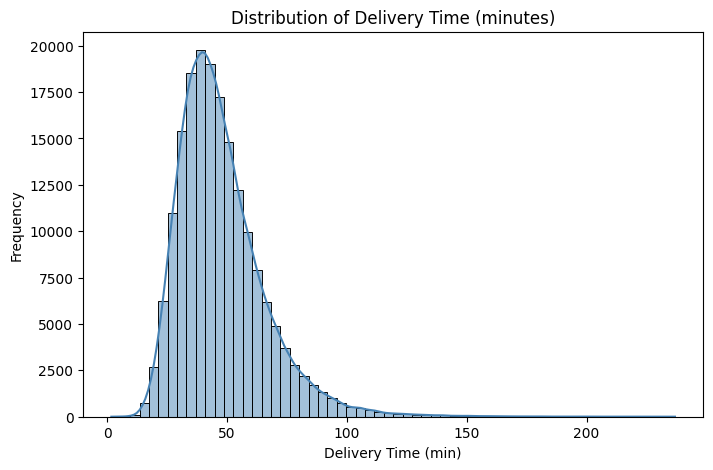

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df["delivery_time_minutes"],bins=60,kde=True,color="steelblue")
plt.title("Distribution of Delivery Time (minutes)")
plt.xlabel("Delivery Time (min)")
plt.ylabel("Frequency")
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap')

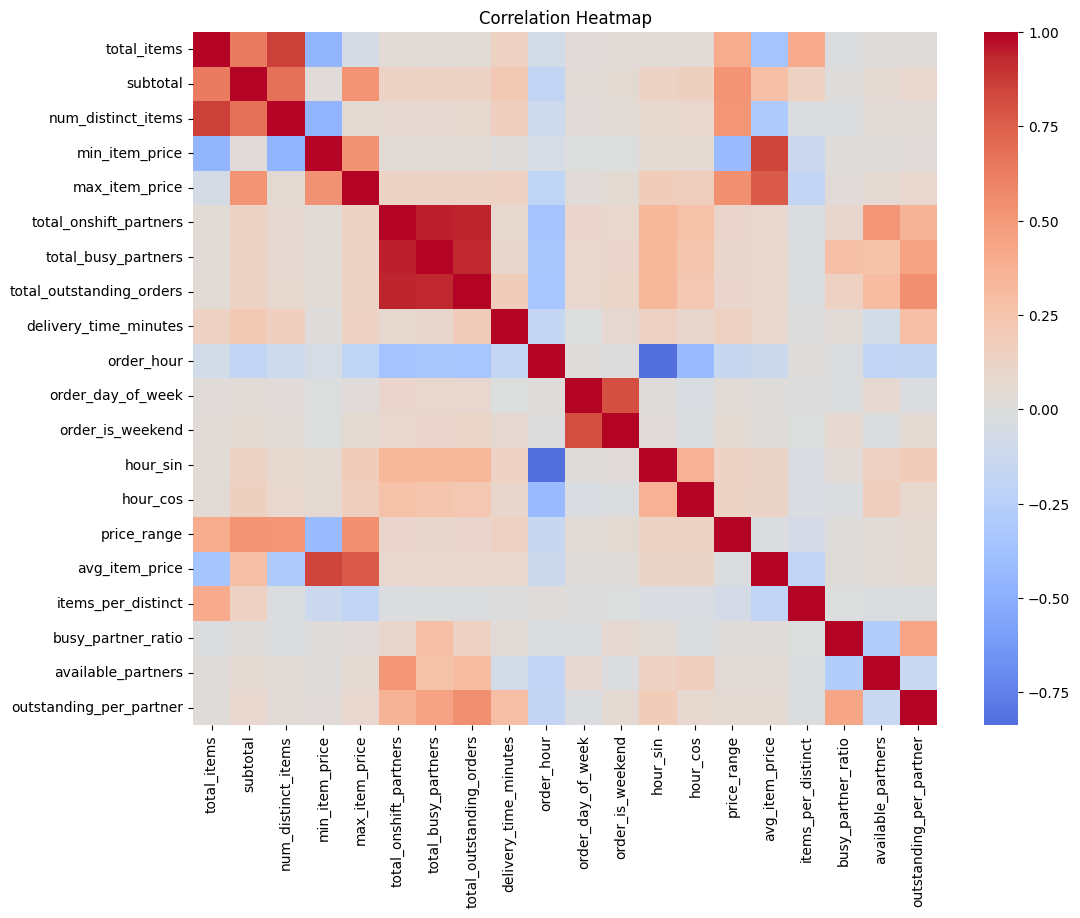

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12, 9))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap")

Text(0.5, 1.0, 'Delivery Time by Hour of Day')

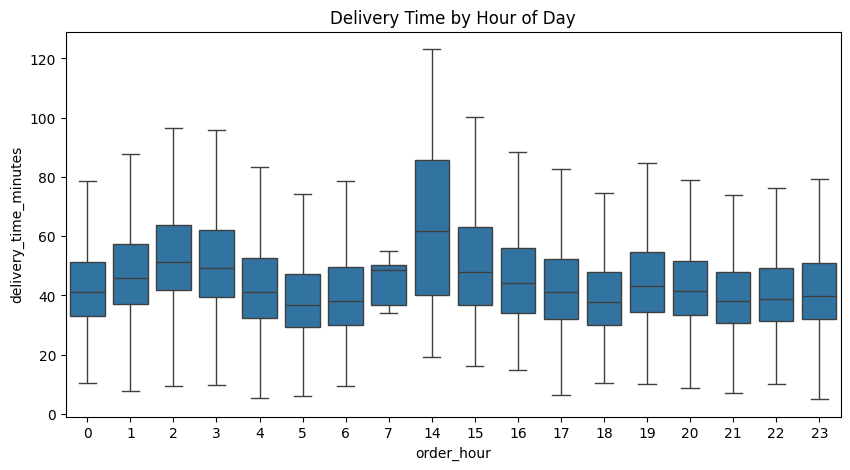

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="order_hour", y="delivery_time_minutes", data=df, showfliers=False)
plt.title("Delivery Time by Hour of Day")

Text(0.5, 1.0, 'Delivery Time by Store Category (Top 10)')

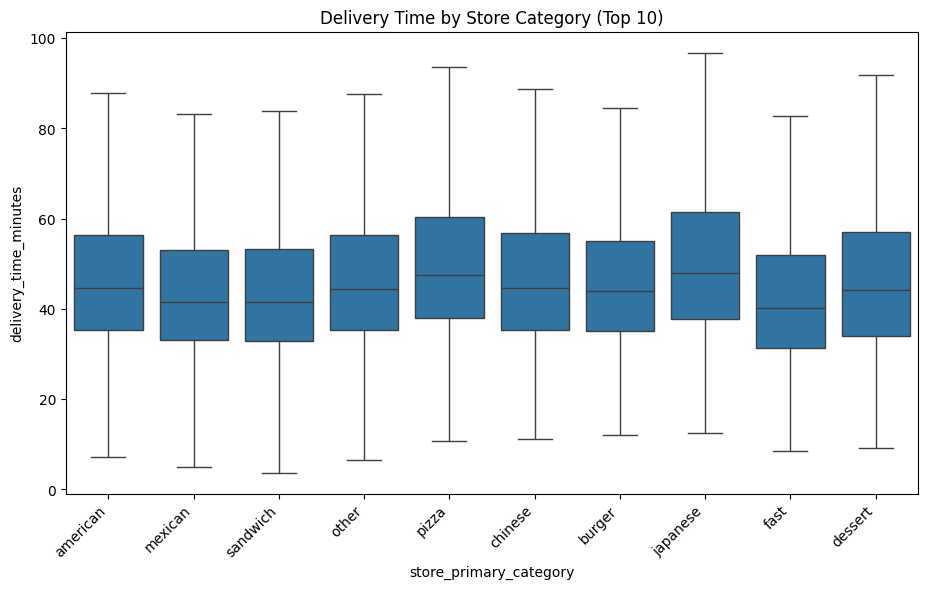

In [ ]:
top_cats = df["store_primary_category"].value_counts().nlargest(10).index
plt.figure(figsize=(11, 6))
sns.boxplot(
    x="store_primary_category", y="delivery_time_minutes",
    data=df[df["store_primary_category"].isin(top_cats)], showfliers=False
)
plt.xticks(rotation=45, ha="right")
plt.title("Delivery Time by Store Category (Top 10)")

Text(0.5, 1.0, 'Outstanding Orders vs Delivery Time')

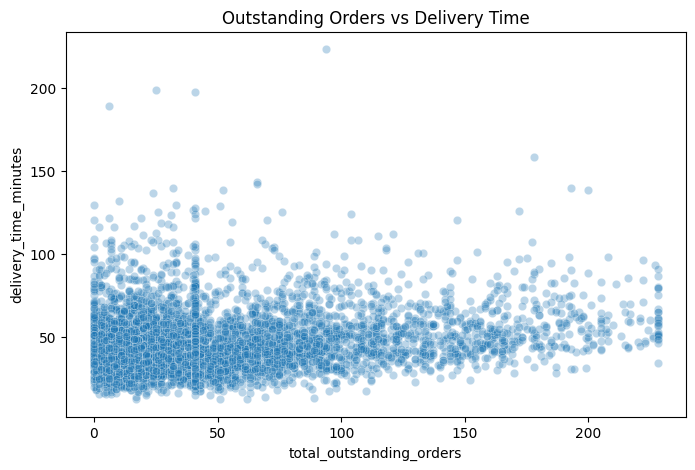

In [ ]:
plt.figure(figsize=(8, 5))
sample = df.sample(min(5000, len(df)), random_state=RANDOM_STATE)
sns.scatterplot(x="total_outstanding_orders", y="delivery_time_minutes", data=sample, alpha=0.3)
plt.title("Outstanding Orders vs Delivery Time")

In [ ]:
NUMERIC_FEATURES = [
    "total_items", "subtotal", "num_distinct_items", "min_item_price",
    "max_item_price", "total_onshift_partners", "total_busy_partners",
    "total_outstanding_orders", "order_hour", "order_day_of_week",
    "order_is_weekend", "hour_sin", "hour_cos", "price_range",
    "avg_item_price", "items_per_distinct", "busy_partner_ratio",
    "available_partners", "outstanding_per_partner",
]
CATEGORICAL_FEATURES = ["market_id", "order_protocol", "store_primary_category"]
TARGET = "delivery_time_minutes"

In [ ]:
feature_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES
X = df[feature_cols].copy()
y = df[TARGET].copy()

X = pd.get_dummies(X, columns=CATEGORICAL_FEATURES, drop_first=False)

feature_columns = X.columns.tolist()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE
)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers, callbacks

input_dim = X_train_scaled.shape[1]

In [ ]:
model = keras.Sequential([
  layers.Input(shape=(input_dim,)),
  layers.Dense(256, activation="relu"),
  layers.BatchNormalization(),
  layers.Dropout(0.3),

  layers.Dense(128, activation="relu"),
  layers.BatchNormalization(),
  layers.Dropout(0.3),

  layers.Dense(64, activation="relu"),
  layers.BatchNormalization(),
  layers.Dropout(0.2),

  layers.Dense(32, activation="relu"),
  layers.Dense(1, activation="linear"),
])
model.compile(
  optimizer=keras.optimizers.Adam(learning_rate=1e-3),
  loss="huber",
  metrics=["mae"],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        13,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,625 (229.00 KB)

 Trainable params: 57,729 (225.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6
)

In [ ]:
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=2,
)

Epoch 1/200
501/501 - 12s - 24ms/step - loss: 19.4889 - mae: 19.9819 - val_loss: 10.9648 - val_mae: 11.4544 - learning_rate: 0.0010
Epoch 2/200
501/501 - 2s - 3ms/step - loss: 11.6221 - mae: 12.1125 - val_loss: 10.9118 - val_mae: 11.4018 - learning_rate: 0.0010
Epoch 3/200
501/501 - 2s - 4ms/step - loss: 11.4376 - mae: 11.9275 - val_loss: 10.8109 - val_mae: 11.3004 - learning_rate: 0.0010
Epoch 4/200
501/501 - 2s - 4ms/step - loss: 11.3238 - mae: 11.8135 - val_loss: 10.7624 - val_mae: 11.2523 - learning_rate: 0.0010
Epoch 5/200
501/501 - 2s - 5ms/step - loss: 11.2502 - mae: 11.7402 - val_loss: 10.7160 - val_mae: 11.2052 - learning_rate: 0.0010
Epoch 6/200
501/501 - 2s - 3ms/step - loss: 11.1854 - mae: 11.6753 - val_loss: 10.6817 - val_mae: 11.1714 - learning_rate: 0.0010
Epoch 7/200
501/501 - 2s - 3ms/step - loss: 11.1332 - mae: 11.6227 - val_loss: 10.6613 - val_mae: 11.1509 - learning_rate: 0.0010
Epoch 8/200
501/501 - 2s - 3ms/step - loss: 11.1018 - mae: 11.5917 - val_loss: 10.6570 -

In [ ]:
y_pred = model.predict(X_test_scaled).flatten()

858/858 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mae

11.08490338831724

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse

np.float64(15.832647730627388)

In [ ]:
r2 = r2_score(y_test, y_pred)
r2

0.2698877012300679

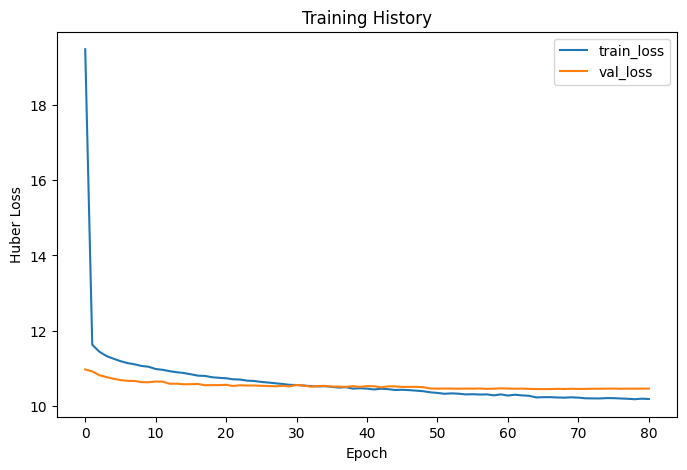

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.title("Training History")
plt.legend()

Text(0.5, 1.0, 'Predicted vs Actual')

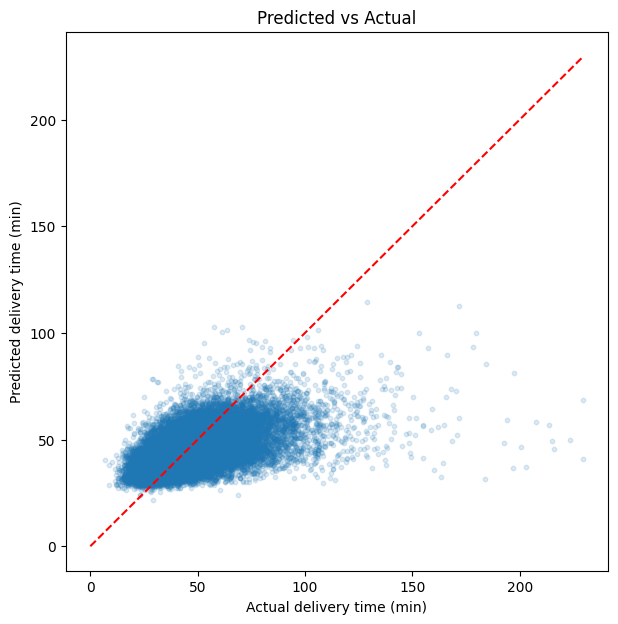

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.15, s=10)
lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual delivery time (min)")
plt.ylabel("Predicted delivery time (min)")
plt.title("Predicted vs Actual")

In [ ]:
import pickle
pickle_out = open('model.pkl', 'wb')
pickle.dump(model, pickle_out)
pickle_out.close()

In [ ]:
pickle_out = open('scaler.pkl', 'wb')
pickle.dump(scaler, pickle_out)
pickle_out.close()

In [ ]:
pickle_out = open('feature_columns.pkl', 'wb')
pickle.dump(feature_columns, pickle_out)
pickle_out.close()

In [ ]:
category_reference = {
    "market_id": sorted(df["market_id"].unique().tolist()),
    "order_protocol": sorted(df["order_protocol"].unique().tolist()),
    "store_primary_category": sorted(df["store_primary_category"].unique().tolist()),
}

In [ ]:
pickle_out = open('category_reference.pkl', 'wb')
pickle.dump(category_reference, pickle_out)
pickle_out.close()

In [ ]:
metrics = {"mae": mae, "rmse": rmse, "r2": r2, "n_test": len(y_test)}
pickle_out = open('metrics.json', 'wb')
pickle.dump(metrics, pickle_out)
pickle_out.close()

In [ ]:
df.sample(min(2000, len(df)), random_state=RANDOM_STATE).to_csv(
        "sample_data.csv", index=False
)